In [4]:
""" This modules applies the final decisions of pre-processing made in 'before_pre-processing.ipynb' directory. 

The strategy:
1. Drop useless features.
2. Create binary column for selected features.
3. Fill missing values using decided methods(LOCF, Mean, Median, etc.).
4. Replace outliers with 'NaN' or 'Unknown'.
5. Fill or remove the new nulls.
6. Re-check for any outliers.
7. Export processed data in a new csv file.
"""

" This modules applies the final decisions of pre-processing made in 'before_pre-processing.ipynb' directory. \n\nThe strategy:\n1. Drop useless features.\n2. Create binary column for selected features.\n3. Fill missing values using decided methods(LOCF, Mean, Median, etc.).\n4. Replace outliers with 'NaN' or 'Unknown'.\n5. Fill or remove the new nulls.\n6. Re-check for any outliers.\n7. Export processed data in a new csv file.\n"

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv("Datasets\\raw\\Dataset.csv")

In [7]:
"""
Removing Features:

1. Hour & Unnamed: 0
These are simply sequential row counters generated when the individual patient files were merged into a single CSV. 
The true medical metric for time elapsed in the ICU is ICULOS, making these columns mathematically redundant.

2. Unit2
This is a binary indicator for the ICU unit that is perfectly inversely correlated with Unit1 (if one is 1, the other is 0). 
Keeping both causes multicollinearity in machine learning models, so we drop this and keep Unit1.

3. SaO2
Arterial oxygen saturation is ~96.5% missing because it requires a painful arterial blood draw. 
We already have O2Sat from the continuous finger pulse oximeter (~13% missing), which provides the exact same oxygenation signal.

4. BaseExcess
This is ~94.5% missing and clinically redundant for a baseline model. 
The patient's metabolic and acid-base balance is already perfectly captured by the core features we kept: pH, PaCO2, and HCO3

5. EtCO2
Missing in ~96.3% of rows because it is primarily monitored only when patients are intubated and on a mechanical ventilator. 
Respiratory distress is already well-covered by our Resp and O2Sat features without introducing this massive sparsity.

6. TroponinI
This is a highly specific biomarker for heart attacks (myocardial infarction), missing in ~99.0% of rows. 
It is too sparse to be useful for a generalized baseline sepsis model, and imputing it would just create noise.

7. Bilirubin_direct, Bilirubin_total, AST, Alkalinephos
These liver enzymes are >98% missing across the dataset. While liver dysfunction can happen in severe sepsis, 
imputing columns that are nearly 100% empty will just create flat, useless data arrays for the model.

8. Fibrinogen & PTT
These secondary coagulation markers are >97% missing. We are already keeping Platelets, 
which is the primary and most important indicator for sepsis-induced blood clotting issues (DIC), 
making these redundant and too sparse to keep.

Total features dropped = 13
"""

"\nRemoving Features:\n\n1. Hour & Unnamed: 0\nThese are simply sequential row counters generated when the individual patient files were merged into a single CSV. \nThe true medical metric for time elapsed in the ICU is ICULOS, making these columns mathematically redundant.\n\n2. Unit2\nThis is a binary indicator for the ICU unit that is perfectly inversely correlated with Unit1 (if one is 1, the other is 0). \nKeeping both causes multicollinearity in machine learning models, so we drop this and keep Unit1.\n\n3. SaO2\nArterial oxygen saturation is ~96.5% missing because it requires a painful arterial blood draw. \nWe already have O2Sat from the continuous finger pulse oximeter (~13% missing), which provides the exact same oxygenation signal.\n\n4. BaseExcess\nThis is ~94.5% missing and clinically redundant for a baseline model. \nThe patient's metabolic and acid-base balance is already perfectly captured by the core features we kept: pH, PaCO2, and HCO3\n\n5. EtCO2\nMissing in ~96.3% 

In [8]:
features_to_drop = ['Bilirubin_direct', 'Bilirubin_total', 'AST', 'Alkalinephos', 'Fibrinogen', 
                    'PTT', 'TroponinI', 'EtCO2', 'BaseExcess', 'SaO2', 'Unit2', 'Hour', 'Unnamed: 0']

df = df.drop(columns=features_to_drop, errors='ignore')

df.shape

(1552210, 31)

In [9]:
# Dictionary of (min, max) physiological limits for vitals
vital_limits = {
    'HR': (20.0, 280.0),
    'MAP': (30.0, 200.0),
    'SBP': (40.0, 250.0),
    'DBP': (20.0, 160.0),
    'O2Sat': (50.0, 100.0),
    'Resp': (4.0, 60.0),
    'Temp': (24.0, 43.0)
}

# Loop through the dictionary and replace values outside the limits with NaN
for col, (min_val, max_val) in vital_limits.items():
    if col in df.columns:
        # Keep the value if it's within bounds, otherwise turn it to NaN
        df[col] = df[col].where((df[col] >= min_val) & (df[col] <= max_val), np.nan)

total_rows = df.shape[0]
print("Vital signs successfully clipped to physiological limits.")

Vital signs successfully clipped to physiological limits.


In [10]:
# 1. Drop the anomalous Patient 13777 (HospAdmTime outlier)
# We use .copy() to prevent Pandas from throwing a "SettingWithCopy" warning later
df = df[df['Patient_ID'] != 13777].copy()

# 2. Fill missing values in Unit1 with -1 (meaning: "Unknown Unit")
if 'Unit1' in df.columns:
    df['Unit1'] = df['Unit1'].fillna(-1)

print(f"Patient 13777 removed. New dataset shape: {df.shape}")
print("Unit1 missing values successfully filled with -1.")

Patient 13777 removed. New dataset shape: (1552202, 31)
Unit1 missing values successfully filled with -1.


In [11]:
# Dictionary of (min, max) physiological limits for surviving Lab values
lab_limits = {
    'HCO3': (2.0, 60.0),
    'FiO2': (0.20, 1.0),
    'pH': (6.5, 8.0),
    'PaCO2': (5.0, 120.0),
    'BUN': (1.0, 300.0),
    'Calcium': (1.0, 20.0),
    'Chloride': (20.0, 160.0),
    'Creatinine': (0.1, 30.0),
    'Glucose': (10.0, 1500.0),
    'Lactate': (0.1, 30.0),
    'Magnesium': (0.1, 15.0),
    'Phosphate': (0.1, 20.0),
    'Potassium': (1.0, 10.0),
    'Hct': (5.0, 75.0),
    'Hgb': (2.0, 30.0),
    'WBC': (0.1, 300.0),
    'Platelets': (1.0, 3000.0)
}

for col, (min_val, max_val) in lab_limits.items():
    if col in df.columns:
        # Keep the value if it's within bounds, otherwise turn it to NaN
        df[col] = df[col].where((df[col] >= min_val) & (df[col] <= max_val), np.nan)

print("Laboratory values successfully clipped to physiological limits.")

Laboratory values successfully clipped to physiological limits.


In [12]:
# The columns we DO NOT need binary flags for (Demographics, Target, and ID)
ignore_cols = ['Patient_ID', 'Age', 'Gender', 'Unit1', 'HospAdmTime', 'ICULOS', 'SepsisLabel']

# Dynamically grab all the remaining clinical columns (your Vitals and Labs)
clinical_cols = [col for col in df.columns if col not in ignore_cols]

# Loop through and create a new binary column for each
for col in clinical_cols:
    # .notna() returns True/False. .astype(int) converts it to 1/0.
    df[f"{col}_Measured"] = df[col].notna().astype(int)

print(f"Successfully generated {len(clinical_cols)} binary '_Measured' columns.")
print(f"New dataset shape: {df.shape}")

Successfully generated 24 binary '_Measured' columns.
New dataset shape: (1552202, 55)


In [13]:
# 1. Fix impossible Blood Pressures (SBP must be >= MAP, which must be >= DBP)
invalid_bp = (df['SBP'] < df['MAP']) | (df['MAP'] < df['DBP']) | (df['SBP'] < df['DBP'])

# Convert ONLY the broken BP readings to NaN, keeping the rest of the row intact
df.loc[invalid_bp, ['SBP', 'MAP', 'DBP']] = np.nan
print(f"Cleaned up {invalid_bp.sum()} impossible blood pressure readings.")

# 2. Fix physically impossible Hgb / Hct ratios
# Hct should be roughly 3x Hgb. If Hct is less than Hgb, or > 5x Hgb, the lab machine broke.
invalid_blood = (df['Hct'] < df['Hgb']) | (df['Hct'] > (df['Hgb'] * 5))

# Convert the broken blood labs to NaN
df.loc[invalid_blood, ['Hct', 'Hgb']] = np.nan
print(f"Cleaned up {invalid_blood.sum()} impossible Hgb/Hct ratios.")

Cleaned up 7589 impossible blood pressure readings.
Cleaned up 3 impossible Hgb/Hct ratios.


In [14]:
# 1. Explicitly list the administrative and static columns to ignore
ignore_cols = ['Patient_ID', 'Age', 'Gender', 'Unit1', 'HospAdmTime', 'ICULOS', 'SepsisLabel']

# 2. Dynamically select ONLY the Vitals and Labs
# Logic: If it's not in the ignore list, AND it doesn't end with '_Measured', keep it.
cols_to_ffill = [col for col in df.columns if col not in ignore_cols and not col.endswith('_Measured')]

# 3. Group by Patient_ID and forward-fill their specific clinical history
df[cols_to_ffill] = df.groupby('Patient_ID')[cols_to_ffill].ffill()

print(f"Phase-1 Complete. Successfully forward-filled {len(cols_to_ffill)} clinical features.")

Phase-1 Complete. Successfully forward-filled 24 clinical features.


In [15]:
""" Nulls Percentage in each feature"""
(df.isnull().mean()*100).sort_values(ascending=False)

Lactate                70.182167
HCO3                   56.523378
FiO2                   56.401229
PaCO2                  55.754341
pH                     54.518484
Chloride               53.570476
Phosphate              42.811052
Calcium                28.468846
Magnesium              27.902683
WBC                    22.538175
Platelets              22.348766
Creatinine             21.396442
Hgb                    21.013373
DBP                    20.715667
BUN                    20.545973
Hct                    19.485350
Potassium              18.259930
Glucose                14.616719
Temp                    7.420362
SBP                     3.920946
Resp                    3.190629
MAP                     2.802148
O2Sat                   2.458829
HR                      2.284303
Age                     0.000000
Gender                  0.000000
Unit1                   0.000000
HospAdmTime             0.000000
ICULOS                  0.000000
SepsisLabel             0.000000
Patient_ID

In [16]:
df.median()

HR                        83.00
O2Sat                     98.00
Temp                      36.83
SBP                      121.00
MAP                       81.00
DBP                       62.00
Resp                      18.00
HCO3                      24.00
FiO2                       0.40
pH                         7.39
PaCO2                     40.00
BUN                       17.00
Calcium                    8.30
Chloride                 106.00
Creatinine                 0.90
Glucose                  122.00
Lactate                    1.58
Magnesium                  2.00
Phosphate                  3.30
Potassium                  4.00
Hct                       31.20
Hgb                       10.40
WBC                       10.30
Platelets                190.00
Age                       64.00
Gender                     1.00
Unit1                      0.00
HospAdmTime               -6.03
ICULOS                    21.00
SepsisLabel                0.00
Patient_ID             19965.00
HR_Measu

In [17]:
# Phase 2: Global Baseline Fallback (Using your newly calculated post-cleaning medians)
global_medians = {
    # Vitals
    'HR': 83.00, 'O2Sat': 98.00, 'Temp': 36.83, 'SBP': 121.00, 'MAP': 81.00, 'DBP': 62.00, 'Resp': 18.00,
    
    # Labs (Using your precise new numbers, but locking FiO2 to clinical room air)
    'Calcium': 8.30, 'Chloride': 106.00, 'Potassium': 4.00, 'Magnesium': 2.00, 
    'Hgb': 10.40, 'Hct': 31.20, 'FiO2': 0.21, 'pH': 7.39, 'PaCO2': 40.00, 'HCO3': 24.00, 
    'BUN': 17.00, 'Creatinine': 0.90, 'Glucose': 122.00, 'Lactate': 1.58, 
    'WBC': 10.30, 'Platelets': 190.00, 'Phosphate': 3.30
}

# Fill the remaining empty slots
for col, median_val in global_medians.items():
    if col in df.columns:
        df[col] = df[col].fillna(median_val)

print("Phase 2 Complete: Remaining missing values filled with global baselines.")

Phase 2 Complete: Remaining missing values filled with global baselines.


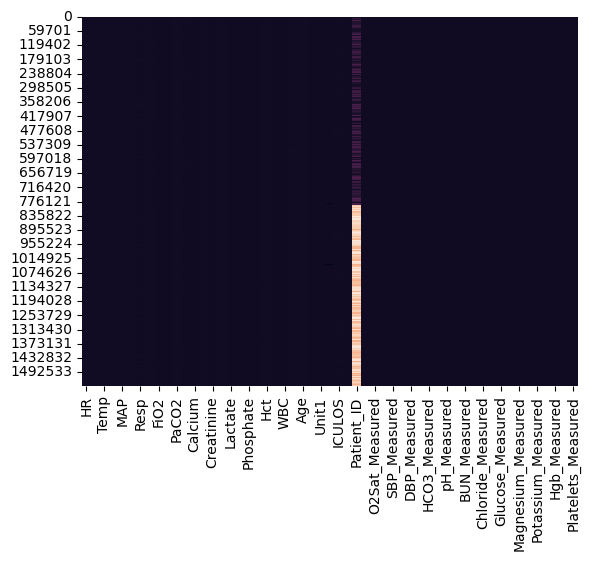

In [18]:
sns.heatmap(df, cbar=False)
plt.show()

In [19]:
df.isnull().sum()

HR                     0
O2Sat                  0
Temp                   0
SBP                    0
MAP                    0
DBP                    0
Resp                   0
HCO3                   0
FiO2                   0
pH                     0
PaCO2                  0
BUN                    0
Calcium                0
Chloride               0
Creatinine             0
Glucose                0
Lactate                0
Magnesium              0
Phosphate              0
Potassium              0
Hct                    0
Hgb                    0
WBC                    0
Platelets              0
Age                    0
Gender                 0
Unit1                  0
HospAdmTime            0
ICULOS                 0
SepsisLabel            0
Patient_ID             0
HR_Measured            0
O2Sat_Measured         0
Temp_Measured          0
SBP_Measured           0
MAP_Measured           0
DBP_Measured           0
Resp_Measured          0
HCO3_Measured          0
FiO2_Measured          0


In [20]:
# Save the cleaned dataframe to a new CSV file
# index=False is crucial! Otherwise, Pandas will generate a new 'Unnamed: 0' column
# and bring back the exact garbage deleted in Step 1!

df.to_csv('Datasets\\processed\\sepsis_icu_cleaned.csv', index=False)

print("Data successfully exported! Safe to close the notebook.")

Data successfully exported! Safe to close the notebook.
